In [1]:
!pwd

/content


__PPI_radar Charts: G7 Countries - 5 Macroeconomic variables__
- Bayesian/Probabilistic Prediction Intervals

Extracted Data:
Unemployment Rate: [np.float64(9.97), np.float64(9.37), np.float64(2.34), np.float64(16.42), np.float64(35.97), np.float64(18.01), np.float64(6.68)]
REER: [np.float64(4.66), np.float64(18.41), np.float64(8.94), np.float64(6.53), np.float64(15.08), np.float64(9.87), np.float64(8.94)]
SIR: [np.float64(5.77), np.float64(15.59), np.float64(7.59), np.float64(4.17), np.float64(21.83), np.float64(10.03), np.float64(8.34)]
Oil Price (WTI): [np.float64(19.85), np.float64(21.27), np.float64(21.31), np.float64(19.88), np.float64(19.09), np.float64(19.25), np.float64(20.88)]
CPI Inflation: [np.float64(9.35), np.float64(55.47), np.float64(5.89), np.float64(7.05), np.float64(32.96), np.float64(14.0), np.float64(8.13)]


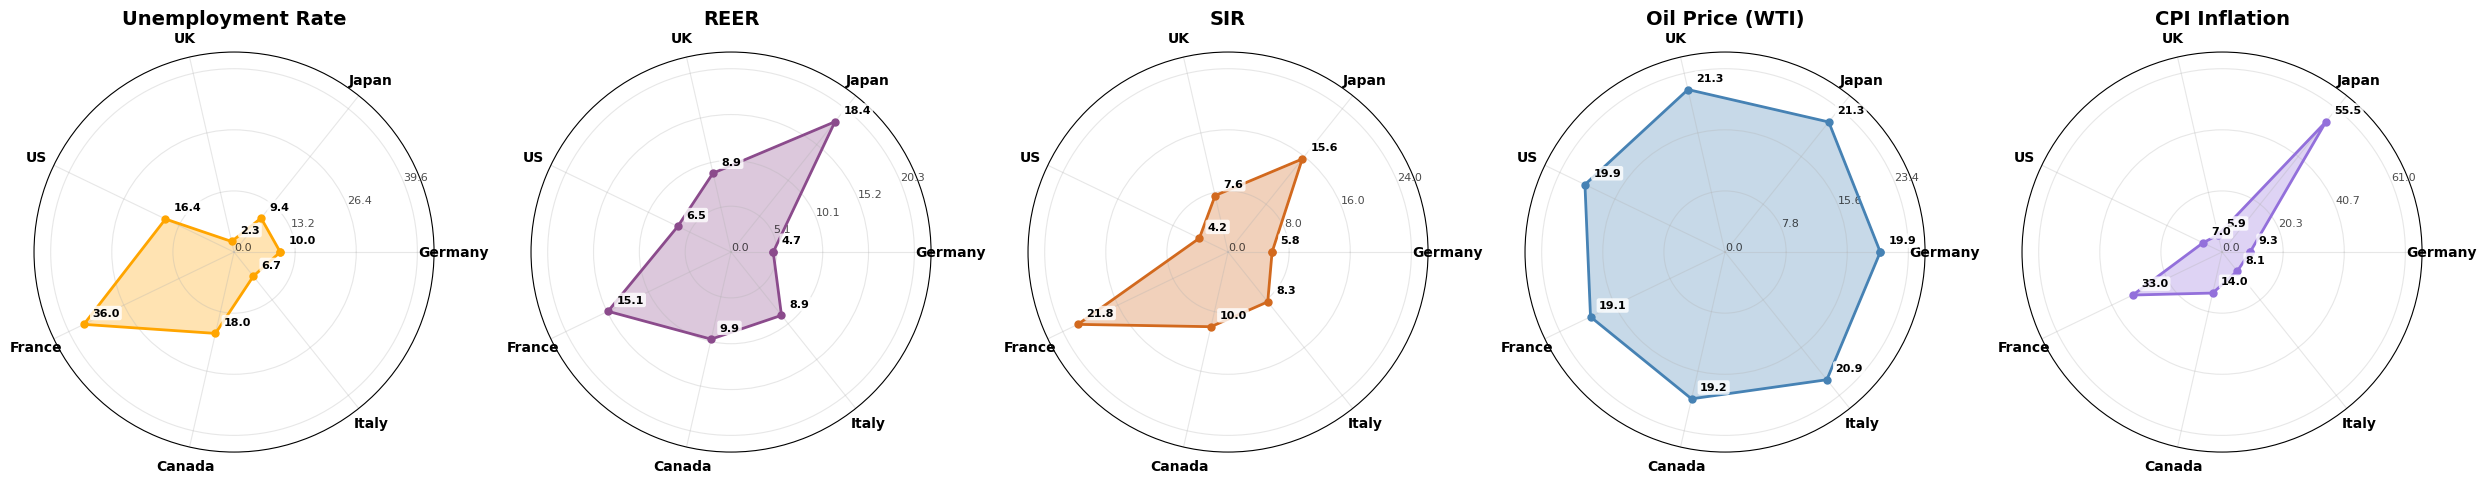


Summary Statistics:
Variable        Min      Max      Mean     Best Country Worst Country
--------------------------------------------------------------------------------
Unemployment Rate 2.3      36.0     14.1     UK           France      
REER            4.7      18.4     10.3     Germany      Japan       
SIR             4.2      21.8     10.5     US           France      
Oil Price (WTI) 19.1     21.3     20.2     France       UK          
CPI Inflation   5.9      55.5     19.0     UK           Japan       

Note: Lower interval widths indicate better prediction precision
Chart saved as: probabilistic_prediction_intervals_avg_width_g7.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data
df = pd.read_csv('summary_all_BPPI_G7_24M.csv')

# Define the specific order of variables as requested
variables_order = [
    'Unemploymentrate',
    'RealbroadEER',
    'ShorttermIR',
    'OilpriceGlobalWTI',
    'CPIinflationrate'
]

# Define variable display names
variable_names = [
    'Unemployment Rate',
    'REER',
    'SIR',
    'Oil Price (WTI)',
    'CPI Inflation'
]

# G7 countries in the order they appear in the data
countries = ['Germany', 'Japan', 'UK', 'US', 'France', 'Canada', 'Italy']

# Extract data for each variable
data = {}
for var in variables_order:
    values = []
    for country in countries:
        # Filter data for specific variable and country
        value = df[(df['Variable'] == var) & (df['country'].str.lower() == country.lower())]['avg_interval_width_PPI'].values
        if len(value) > 0:
            values.append(value[0])
        else:
            values.append(0)  # fallback if data missing
    data[var] = values

# Print the extracted data for verification
print("Extracted Data:")
for i, var in enumerate(variables_order):
    print(f"{variable_names[i]}: {data[var]}")

# Number of countries
N = len(countries)

# Calculate angles for radar chart
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Create figure with 5 subplots in a row
fig, axes = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(projection='polar'))

# Color palette matching the reference image style
colors = ['#FFA500', '#8B4B8C', '#D2691E', '#4682B4', '#9370DB']

# Create radar chart for each variable
for idx, var in enumerate(variables_order):
    ax = axes[idx]
    values = data[var]

    # Close the plot by adding first value at the end
    values_plot = values + [values[0]]

    # Plot the radar chart
    ax.plot(angles, values_plot, 'o-', linewidth=2, color=colors[idx], markersize=5)
    ax.fill(angles, values_plot, alpha=0.3, color=colors[idx])

    # Customize each subplot
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(countries, fontsize=10, fontweight='bold')

    # Set y-axis limits based on the data range for each variable
    max_val = max(values)
    ax.set_ylim(0, max_val * 1.2)

    # Set y-axis ticks
    if max_val > 20:
        num_ticks = 4
    else:
        num_ticks = 5

    ticks = np.linspace(0, max_val * 1.1, num_ticks)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{tick:.1f}' for tick in ticks], fontsize=8, alpha=0.7)

    # Add grid
    ax.grid(True, alpha=0.3)

    # Add variable title
    ax.set_title(variable_names[idx], fontsize=14, fontweight='bold', pad=20)

    # Add value labels on points
    for angle, value, country in zip(angles[:-1], values, countries):
        # Position labels slightly outside the points
        ax.annotate(f'{value:.1f}',
                    xy=(angle, value),
                    xytext=(6, 6),
                    textcoords='offset points',
                    fontsize=8,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Remove any extra spacing and adjust layout
plt.tight_layout()

# Save as PNG file
plt.savefig('probabilistic_prediction_intervals_avg_width_g7.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("=" * 80)
print(f"{'Variable':<15} {'Min':<8} {'Max':<8} {'Mean':<8} {'Best Country':<12} {'Worst Country':<12}")
print("-" * 80)

for i, var in enumerate(variables_order):
    values = data[var]
    min_val = min(values)
    max_val = max(values)
    mean_val = np.mean(values)
    best_country = countries[values.index(min_val)]
    worst_country = countries[values.index(max_val)]
    print(f"{variable_names[i]:<15} {min_val:<8.1f} {max_val:<8.1f} {mean_val:<8.1f} {best_country:<12} {worst_country:<12}")

print("\nNote: Lower interval widths indicate better prediction precision")
print("Chart saved as: probabilistic_prediction_intervals_avg_width_g7.png")